In [1]:
from src.Architecture.DummyGPTModel import DummyGPTModel
from src.Architecture.ExampleDeepNeuralNetwork import ExampleDeepNeuralNetwork
from src.Attention.CausalAttention import CausalAttention

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "embedding_dim": 768,
    "num_heads": 12, # Number of attention heads in the multi-head attention mechanism.
    "num_layers": 12, # Number of transformer blocks.
    "dropout": 0.1,
    "qkv_bias": False, # Whether to add bias vector to the queries, keys, and values.
}

We will implement a GPT placeholder architecture to provide an overview of how everything fits together and what other components we need to code. Then we will implement a final version.

Next, we prepare the input data and initialize a new GPT model to illustrate its usage. Building on our coding of the tokenizer, let's now consider a high-level overview of how data flows... We tokenize a batch consisting of two inputs for the GPT model using the tiktoken tokenizer:

In [2]:
import tiktoken
import torch

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0) # Stacks the tensors along a new dimension.
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


Next, we initialize a new 124-million parameter DummyGPTModel instance and feed it the tokenized batch:

In [3]:
from src.Architecture.DummyGPTModel import DummyGPTModel

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


The output tensor has two rows corresponding to two text samples. Each text sample consists of four tokens; each token is a 50,257-dimensional vector, which matches the size for the tokenizer's vocabulary.

The embedding has 50,257 dimensions because each of these dimensions refers to a unique token in the vocabulary. When we implement the post-processing code, we will convert back into token IDs, which we can then decode into words.

### Normalizing activations with layer normalization

Training deep neural networks with many layers can sometimes prove challenging due to problems like vanishing or exploding gradients. These problems lead to unstable training dynamics and make it difficult for the network to effectively adjust its weights, which means the learning process struggles to find a set of parameters (weights) for the neural network that minimizes the loss function. In other words, the network has difficulty learning the underlying patterns in the data to a degree that would allow it to make accurate predictions or decisions.

Layer normalization is one method to improve stability and efficiency of neural network training. The main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of zero and variance of 1, also known as unit variance. This adjustment speeds up the covergence to effective weights and ensure consistent, reliable training. In GPT-2 and modern transformer architectures, layer normalization is typically applied before and after the multi-head attention module, and, as we have before the final output layer.

As an example, we can demonstrate layer normalization:

In [4]:
from torch import nn
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


Remember: ReLU (short for rectified linear unit) is a standard activation function that has a simple threshold of 0. Meaning negative values get set to 0 and only positive values are passed along 1 for 1. Later, we will use a more sophisticated activation function in out GPT.

Before we apply layer normalization, let's examine the mean and variance:

In [5]:
mean = out.mean(dim=-1, keepdim=True)
variance = out.var(dim=-1, keepdim=True)
print(
    "Mean of activations:", mean,
    "\nVariance of activations:", variance
)

Mean of activations: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>) 
Variance of activations: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


Using keepdim=True in operations like mean or variance calculations ensure that the output tensor retains the same number of dimensions as the input tensor, even though the operation reduces the tensor along the dimension specified via dim. For instance, without keepdim=True the returned mean tensor would be a two-dimensional vector [0.1324, 0.21701] instead of a 2 x 1-dimensional matrix [[0.1324], [0.2170]].

The dim parameter specifies the dimension along which the calculation of the static should be performed in a tensor. dim=1 or dim=-1 calculates across the column dimension to obtain one statistic per row. Whereas dim=0 calculations mean across the row dimension to obtain one statistic per column.

Next let's apply layer normalization to the layer outputs we obtained earlier. The operation consists of subtracting the mean and dividing by the square root of the variance (aka std).

In [6]:
out_norm = (out - mean) / torch.sqrt(variance)
mean = out_norm.mean(dim=-1, keepdim=True)
variance = out_norm.var(dim=-1, keepdim=True)
print(
    "Mean of activations after normalization:", mean,
    "\nVariance of activations after normalization:", variance
)

Mean of activations after normalization: tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>) 
Variance of activations after normalization: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


We have now coded and applied layer normalization. Let's now codify into a PyTorch module that we can use later.

Now, let's try the LayerNorm module in practice and apply it to the batch input:

In [7]:
from src.Architecture.LayerNorm import LayerNorm

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
variance = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print(
    "Mean of activations after normalization:", mean,
    "\nVariance of activations after normalization:", variance
)

Mean of activations after normalization: tensor([[-6.5565e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>) 
Variance of activations after normalization: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### Layer normalization vs. batch normalization

Batch normalization, which normalizes across the batch dimension, differs from layer normalization which normalized across the feature dimension. LLMs often require significant computation resources, and available hardware or specific use case can dictate the batch size during training or inference. Since layer normalization normalizes each input independently of the batch size, it offers more flexiability and stability in these scenerios. This is particularly beneficial for distributed training or when deploying models in environments where resources are constrained.

### Implementing a feed forward network with GELU activations

Historically, the ReLU activation functions have been used in dep learning due to its simplicity and effectiveness. However, in LLMs, several other activation functions are commonly employed beyond the traditional ReLU. Two notable examples are GELU (Gaussian error linear unit) and SwiGLU (Swish-gated linear unit).

GELU and SwiFLU are more complex and smooth activation functions incorporating Gaussian and sigmoid-gated linear units... They offer improved performance for deep learning models unlike the simple ReLU.

The GELU can be implemented in several ways; the exact version uses the cumulative distribution function of the Gaussian at x multiplied by x where x is the observation. In practice, it is common to implement a computationally cheaper approximation which was found using curve fitting techniques:

GELU(x) ~= 0.5 * x *(1 + tanh[sqrt(2/pi) * (x + 0.044715 * x^3)])

Implemented in python:

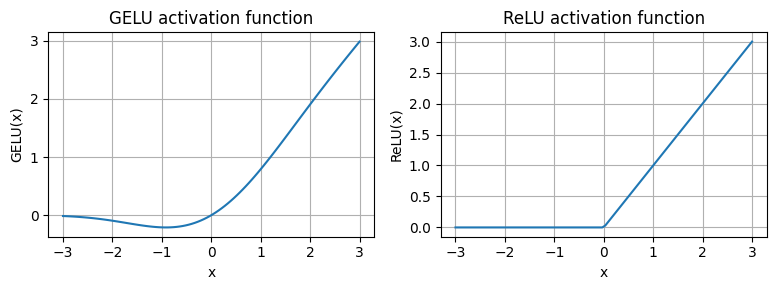

In [8]:
from src.Architecture.GELU import GELU

import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f'{label} activation function')
    plt.xlabel('x')
    plt.ylabel(f'{label}(x)')
    plt.grid(True)
plt.tight_layout()
plt.show()

As we see, ReLU is a piecewise linear function that only outputs positive values. GELU is smooth, nonlinear that approximates ReLU but with a non-zero gradient for almost all negative values (except at approximately x = -0.75)

The smoothness of GELU can lead to better optimization properties during training as it allows for more nuanced adjustments to the model's parameters. In contrast, the ReLU has a sharp corner at zero, which can sometimes make optimization harder, especially in networks that are very deep or have complex architectures.

Alos, unlike ReLU, which outputs zero for any negative input, GELU allows for a small, non-zero output for negative values. This characteristic means that during the training process, neurons that recieve negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs.

Next, let's implement the small neural network module, FeedForward, that we will use in the LLM's transformer block later:

In [9]:
from src.Architecture.FeedForward import FeedForward

ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print("Output shape:", out.shape)

Output shape: torch.Size([2, 3, 768])


As we see, the output tensor is the same size as the input tensor.

Although the input and output dimensions are the same, it internally expands the embedding dimension into a higher dimensional space through the first linear layer. This expansion is followed by a nonlinear GELU activation and then a contraction back to the original dimension with the second linear transformation. Such a design allows for the exploration of a richer representation space.

Moreover, uniformity in input and output dimensions simplifies the architecture by enabling the stacking of multiple layers without needing to adjust dimensions between layers, thus making our model more scalable and easier to reason about.

### Shortcut connections (aka skip or residual connections)

Originally, shortcut connections were proposed for deep networks in computer vision (specifically, in residual networks) (ResNet) to mitigate the challenges of vanishing gradients (where the gradients become increasingly small as you progress through the network. (Generally a problem for larger networks.)

The shortcut connection creates an alternative, shorter path for the gradient to flow through the network by skipping one or more layers, which is achieved by adding the output of one layer to the output of a later layer. This helps to improve the stability of the network.

Let's initialize a neural network without shortcut connections. Each layer will be initialized such that it accepts an exaple with three input values and returns three output values. The last layer returns a single output value:

In [10]:
from src.Architecture.ExampleDeepNeuralNetwork import ExampleDeepNeuralNetwork

layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([1., 0., -1.])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In [11]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of: {param.grad.abs().mean().item():.4f}")

In [12]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of: 0.0002
layers.1.0.weight has gradient mean of: 0.0001
layers.2.0.weight has gradient mean of: 0.0006
layers.3.0.weight has gradient mean of: 0.0013
layers.4.0.weight has gradient mean of: 0.0047


C:\Users\brend\Desktop\PythonVenv\py3_14\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


The gradients become smaller as we progress from the last layer to the first layer, which is a phenomenon called the "vanishing gradient problem."

Now let's enable the skip connections to see how the gradients compare:

In [13]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of: 0.1670
layers.1.0.weight has gradient mean of: 0.1782
layers.2.0.weight has gradient mean of: 0.2485
layers.3.0.weight has gradient mean of: 0.2142
layers.4.0.weight has gradient mean of: 1.0611


The gradients still decrease, but they begin to stabilize as we progress through toward the first layer and doesn't shrink to a vanishingly small value.

### Connecting attention and linear layers in a transformer block

Now let's implement the transformer block, a fundamental building block of GPT and other LLM architectures. This block, which is repeated a dozen times in the 124-million-parameter GPT-2 architecture, combines several concepts we have previously covered: masked multi-head attention, layer normalization, dropout, feed forward layers, and GELU activations. Later, we will connect this transformer block to the remaining parts of the GPT architecture.

When a transformer block processes an input sequence, each element in the sequence (for example, a word or sub word token) is represented by a fixed-size vector (in this case, 768 dimensions). The operations within the transformer block, including multi-head attention and feed forward layers, are designed to transform these vectors in a way that preserves their dimensionality.

The idea is that the self-attention mechanism is the multi-head attention block identifies and analyzes relationships between elements in the input seqeunce. In contrast, the feed forward network modifies the data individually at each position. This combination not only enables a more nuanced understanding and processing of the input but also enhances the model's overall capacity for handling complex data patterns.

In [14]:
# Testing our transformer block
from src.Architecture.TransformerBlock import TransformerBlock

torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


We can see, the transfer block maintains the input dimensions in its output, indicating that the transformer architecture processes sequences of fdata without altering their shape throughout the network.

The preservation of shape is not incidental but a crucial aspect of design. This design enables its effective application across a wide range of sequence-to-sequence tasks, where each output vector directly corresponds to an input vectros, maintaining a one-to-one relationship. However, the output is a context vector that encapsulates information from the entire input sequences. This means while the physical dimensions of the sequence (length and feature size) remains unchanged as it passes through the transformer block, the content of each output vector is re-encoded to integrate contextual information from across the entire input sequence.

### Coding the GPT model

Now let's assemble a fully working version of the original 124-million-parameter version of GPT-2. Later, we will pretrain a GPT-2 model, and also load pre-trained weights from OpenAI.

Before we assemble the GPT-2 model in code, let's look at its overall structure.... In the case of the 124-million parameter GPT-2 model, the transformer block is repeated 12 times. This transformer block is repeated 48 times in the largest GPT-2 model with 1,542 million parameters.

The output from the final transformer block then goes through a final layer normalization step before reaching the linear output layer. This layer maps the transfomers output to a high-dimensional space (in this case, 50,257 dimensions, corresponding to the model's vocabulary size) to predict the next token in the sequence.

Now let's initialize the 124-million-parameter GPT model using the GPT_CONFIG_124 dictionary:

In [15]:
from src.Architecture.GPTModel import GPTModel

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)

print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3612,  0.4223, -0.0712,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1793, -0.5660, -0.9486,  ...,  0.0477,  0.5181, -0.3169],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1017, -0.4326, -0.2553],
         [-1.0076,  0.3419, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2565,  0.0901,  0.0335,  ...,  0.2658,  0.4454, -0.6806],
         [ 0.1229,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2245],
         [ 1.0558,  1.0318, -0.2799,  ...,  0.6935,  0.3205, -0.3178],
         [-0.1567,  0.3928,  0.3288,  ...,  1.2630, -0.1859,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


As we can see, the output tensor has the shape [2, 4, 50257], since we passed in two input texts with four tokens each. The last dimension, 50,257, correspondes to the vocabulary size of the tokenizer. Later we will see how to convert back into tokens.

#### Model parameter and size analysis

Using the numel() method, short for number of elements, we can collect the total number of parameters in the model's parameter tensors:

In [16]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Total number of parameters: 163009536


Notice there are 163 million parameters, not 124 million as expected. Why?

The reason is a concept called "weight typing," which means that the GPT-2 architecture resues the weights from the token embedding layer in its output layer. To understand better, let's take a look at the shapes of the token embedding layer and linear output layer we initialized on the model via the GPTModel earlier:

In [17]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape: ", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape:  torch.Size([50257, 768])


We can see that both layers have the same shape. The token embedding and output layers are very large due to the number of rows for the tokenizer's vocabulary: 50,257. Let's remove the output layer parameter count from the GPT-2 model count according to the weight typing:

In [18]:
total_params_gpt2 = (total_params - sum(p.numel() for p in model.out_head.parameters()))
print(f"Number of trainable parameters in GPT-2 model considering weight tying: {total_params_gpt2}")

Number of trainable parameters in GPT-2 model considering weight tying: 124412160


As we can see, the model parameters now match the original size of the GPT-2 model.

Weight tying reduces the overall memory footprint and computational complexity of the model. However, using seperate token embedding and output layers result in better training and model performance; hence, we use seperate layers in our GPTModel implementation. The same is true from modern LLMs.

Now let's compute the memory requirements:

In [19]:
bytes_per_param = 4 # Assuming 32-bit floats.
total_size_bytes = total_params * bytes_per_param
total_size_mb = total_size_bytes / (1024 * 1024) # convert to megabytes
print(f"Total size of the model: {total_size_mb} MB")

Total size of the model: 621.83203125 MB


### Generating text

Now we implement code that converts the tensor outputs back into text....

The process by which the GPT model goes from output tensors to generated text involves several steps. These steps include decoding the output tensors, selecting tokens based on a probability distribution, and converting these tokens into human-readable text.

In each step, the model outputs a matrix with vectors representing potential next tokens. The vector corresponds to the next token is extracted and converted into a probability distribution via the softmax function. Within the vector containing the resulting probability scores, the index of the highest value is located, which translates to the token Id. This token Id is then decoded back into text, producing the next token in the sequence. Finally, this token is appended to the previous inputs, forming a new input sequence for the subsequent iteration. This step-by-step process enables the model to generate text sequences, building coherent phrases and sentences from the initial context.

This process is repeated until we reach a user-specified number of generated tokens or a stop sequence is generated.

In [24]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_context = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_context)

        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probs, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

This code demonstrates a simple implementation of a generative loop. It iterates for a specified number of new tokens to be generated, crops the current context to fit the model's maximum context size, computes predictions, and then selects the next token based on the highest probability prediction.

We use a softmax function to convert the logits into a probability distribution from which we identify the positions with the highest value via argmax. The softmax is monotonic, meaning it preserves the order of its inputs when transformed into outputs. So, in practice, the softmax step is redundant since the position with the highest score in the softmax output tensor is the same position in the logit tensor. In other words, we could pply the argmax function to the logits tensor directly and get identical results. However, I provide the code for conversation to illustrate the full process of transforming logics to probabilities, which can add additional intuition so the model generates the most likely next token, which is known as "greedy decoding."

In the future we will use additional sampling techniques to modify the softmax outputs such that the model doesn't always reflect the most likely token This introduces variability and creativity in the generated text.


Let's try out the simple generation function:

In [22]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded token Ids: ", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
print("encoded tensor shape: ", encoded_tensor.shape)

encoded token Ids:  [15496, 11, 314, 716]
encoded tensor shape:  torch.Size([1, 4])


In [29]:
model.eval() # disables dropout since we are not training
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=12,
    context_size=GPT_CONFIG_124M['context_length']
)
print("Output (generated tokens): ", out)
print("Output length: ", len(out[0]))

Output (generated tokens):  tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267,
         49706, 43231, 47062, 34657, 18631, 49188]])
Output length:  16


In [30]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous bore ITV


We can see the model generate gibberish since the model is not yet trained. Next, we will tackle training.

Note: we also used the same dropout rate across our architecture (the embedding layer, shortcut layer, and multi-head attention). We could also consider having three distinct parameters.

### In Summary
- Layer normalization stabilizes training by ensuring that each layer's output have a consistent mean and variance.
- Shortcut connections are connections that skip one or more layers by feeding the output of one layer directly to a deeper layer, which helps mitigate the vanishing gradient problem when training deep architectures.
- Transformer blocks are core structural components of the GPT models, combining masked multi-head attention with fully connected feed forward networks that use GELU and skip connections
- Without training, a GPT model generates incoherent text.